In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure # Para CLAHE en color

In [2]:
# --- Funciones Auxiliares para Mostrar Imágenes ---
def mostrar_imagen(titulo, imagen, cmap=None):
    plt.figure(figsize=(8, 6))
    if cmap:
        plt.imshow(imagen, cmap=cmap)
    else:
        # OpenCV carga en BGR, Matplotlib espera RGB
        plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis('off')
    plt.show()

def mostrar_histograma(imagen, titulo="Histograma"):
    if len(imagen.shape) == 3: # Imagen a color
        color = ('b', 'g', 'r')
        for i, col in enumerate(color):
            hist = cv2.calcHist([imagen], [i], None, [256], [0, 256])
            plt.plot(hist, color=col)
        plt.title(f"{titulo} (RGB)")
    else: # Imagen en escala de grises
        hist = cv2.calcHist([imagen], [0], None, [256], [0, 256])
        plt.plot(hist, color='gray')
        plt.title(f"{titulo} (Escala de Grises)")
    plt.xlim([0, 256])
    plt.show()

def show_images(images, titles=None):
    """Display multiple images in a grid."""
    n = len(images)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    for i in range(n):
        image = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
        axes[i].imshow(image)
        if titles:
            axes[i].set_title(titles[i])
        axes[i].axis('off')
    
    for j in range(i + 1, rows * cols):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

def filtro_gris(img, mask, uint8=True):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h1, w1 = img.shape
    h2, w2 = mask.shape
    
    g = np.zeros_like(img, dtype=np.float32)
    for y in range(w1):
        for x in range(h1):
            valor = 0
            s = -h2 // 2
            for j in range(w2):
                t = -w2 // 2
                for i in range(h2):
                    if 0 <= y+t < w1 and 0 <= x+s < h1:
                        valor += mask[i, j] * img[x+s, y+t]
                    t += 1
                s += 1
            g[x, y] = valor
    if uint8:
        return np.clip(g, 0, 255).astype(np.uint8)
    else:
        return np.clip(g, 0, 255)

In [3]:
# Funciones auxiliares para dominio frecuancial

def calcular_dft_centrada(imagen_grayscale):
    dft = cv2.dft(np.float32(imagen_grayscale), flags=cv2.DFT_COMPLEX_OUTPUT)
    return np.fft.fftshift(dft)
    
def mostrar_frecuencias(imagen_grayscale, dft_shift, mostrar_fase=False, titulo='', titulo_magnitud='Espectro de magnitud'):
    real = dft_shift[:, :, 0]
    imag = dft_shift[:, :, 1]
    magnitud = 20 * np.log1p(np.sqrt(real**2 + imag**2))

    if mostrar_fase:
        fase = np.angle(real + 1j * imag)

    n_subplots = 3 if mostrar_fase else 2
    plt.figure(figsize=(12, 4 if not mostrar_fase else 6))

    plt.subplot(1, n_subplots, 1)
    plt.imshow(imagen_grayscale, cmap='gray')
    plt.title('Imagen original' + (f' - {titulo}' if titulo else ''))
    plt.axis('off')

    plt.subplot(1, n_subplots, 2)
    plt.imshow(magnitud, cmap='gray')
    plt.title(titulo_magnitud)
    plt.axis('off')

    if mostrar_fase:
        plt.subplot(1, n_subplots, 3)
        plt.imshow(fase, cmap='gray')
        plt.title('Fase')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    
def reconstruir_imagen_idft(dft_shift, mostrar=False, titulo="Imagen Reconstruida"):
    # Paso 1: Desplazar frecuencias nuevamente
    dft_ishift = np.fft.ifftshift(dft_shift)

    # Paso 2: Aplicar IDFT
    img_back = cv2.idft(dft_ishift)

    # Paso 3: Obtener la magnitud (real e imaginario)
    img_recuperada = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])

    # Paso 4: Normalizar al rango [0, 255]
    img_recuperada = cv2.normalize(img_recuperada, None, 0, 255, cv2.NORM_MINMAX)
    img_recuperada = np.uint8(img_recuperada)

    # Mostrar si se solicita
    if mostrar:
        plt.figure(figsize=(5, 5))
        plt.imshow(img_recuperada, cmap='gray')
        plt.title(titulo)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    return img_recuperada

def crear_mascara_frecuencia(shape, radio, tipo='pasa_bajas', forma='circular'):
    filas, columnas = shape
    centro_fila, centro_columna = filas // 2, columnas // 2

    Y, X = np.ogrid[:filas, :columnas]

    if forma == 'circular':
        distancia = np.sqrt((X - centro_columna)**2 + (Y - centro_fila)**2)
        if tipo == 'pasa_bajas':
            mascara = distancia <= radio
        elif tipo == 'pasa_altas':
            mascara = distancia > radio
        else:
            raise ValueError("Tipo de filtro debe ser 'pasa_bajas' o 'pasa_altas'")
    elif forma == 'cuadrada':
        mitad_lado = radio
        mascara = np.zeros((filas, columnas), dtype=bool)
        if tipo == 'pasa_bajas':
            mascara[
                centro_fila - mitad_lado:centro_fila + mitad_lado,
                centro_columna - mitad_lado:centro_columna + mitad_lado
            ] = True
        elif tipo == 'pasa_altas':
            mascara[:, :] = True
            mascara[
                centro_fila - mitad_lado:centro_fila + mitad_lado,
                centro_columna - mitad_lado:centro_columna + mitad_lado
            ] = False
        else:
            raise ValueError("Tipo de filtro debe ser 'pasa_bajas' o 'pasa_altas'")
    else:
        raise ValueError("Forma debe ser 'circular' o 'cuadrada'")

    # Repetimos para los dos canales (real, imaginario)
    return np.repeat(mascara[:, :, np.newaxis], 2, axis=2).astype(np.float32)

--- Etapa 1: Adquisición y Comprensión Inicial ---


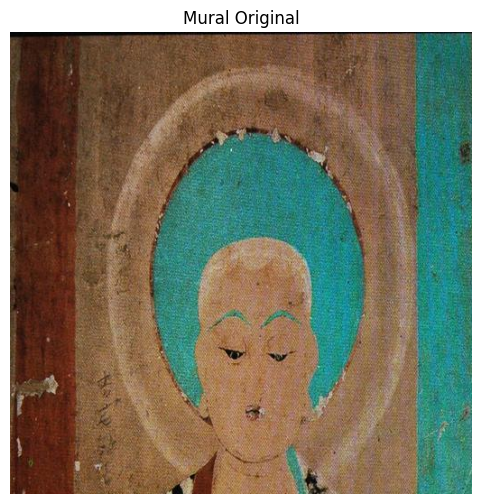

Dimensiones de la imagen: (512, 512, 3)
Tipo de datos: uint8


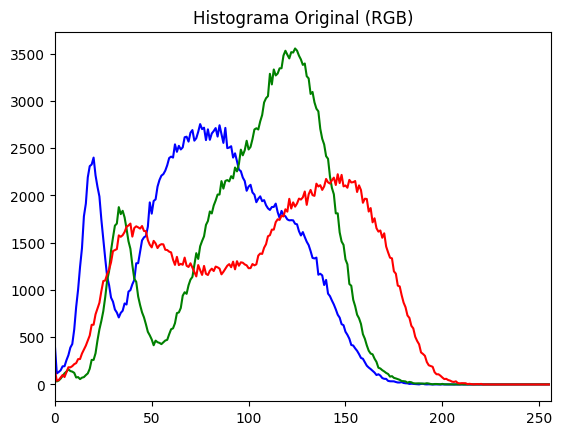

In [4]:
# --- Etapa 1: Adquisición y Comprensión Inicial ---
print("--- Etapa 1: Adquisición y Comprensión Inicial ---")
ruta_imagen = './dataset_mural/img_16crop_0_0.png' 
try:
    img_original = cv2.imread(ruta_imagen)
    if img_original is None:
        raise FileNotFoundError(f"No se pudo cargar la imagen en la ruta: {ruta_imagen}")
except FileNotFoundError as e:
    print(e)
    exit()
except Exception as e:
    print(f"Ocurrió un error al cargar la imagen: {e}")
    exit()

mostrar_imagen("Mural Original", img_original)
print(f"Dimensiones de la imagen: {img_original.shape}") # (alto, ancho, canales)
print(f"Tipo de datos: {img_original.dtype}")
mostrar_histograma(img_original, "Histograma Original")


--- Etapa 2: Preprocesamiento ---


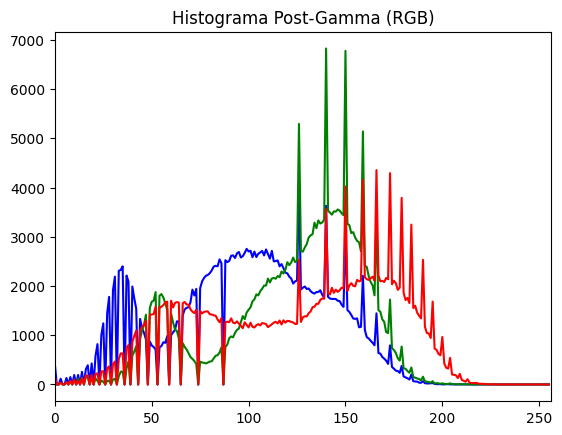

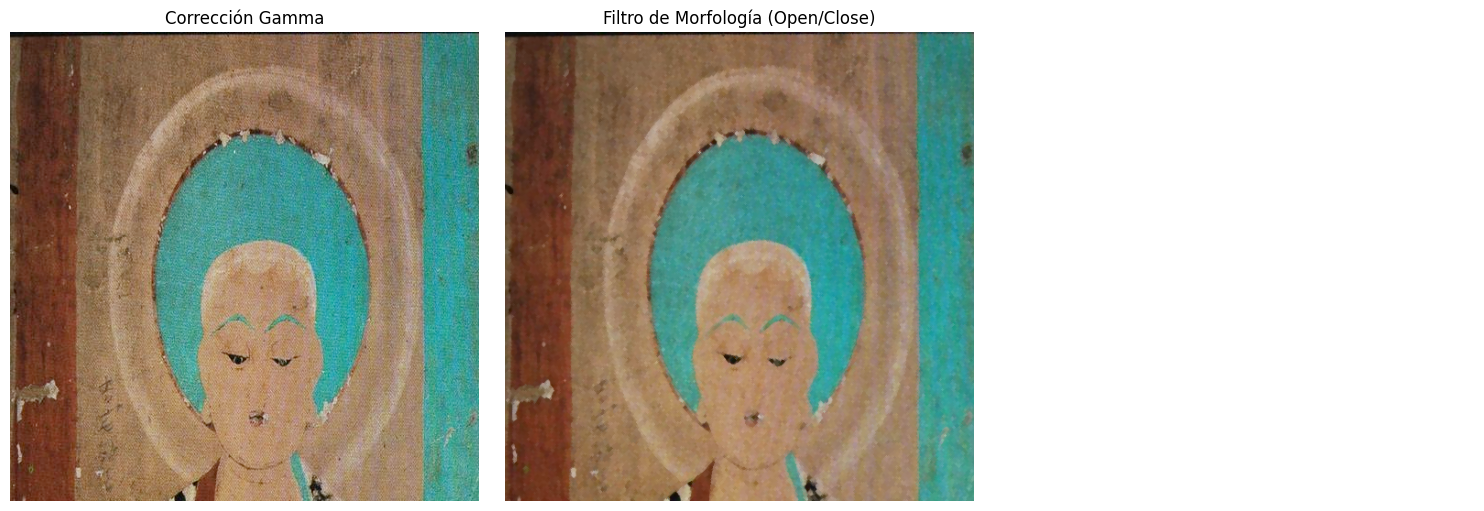

In [5]:
# --- Etapa 2: Preprocesamiento: Corrección y Preparación ---
print("\n--- Etapa 2: Preprocesamiento ---")

# 2.1 Corrección Gamma (Ajuste de Luminosidad)
# Una gamma > 1 aclara, < 1 oscurece.
gamma = 1.3
tabla_gamma = np.array([((i / 255.0) ** (1.0 / gamma)) * 255
                        for i in np.arange(0, 256)]).astype("uint8")
img_gamma_corregida = cv2.LUT(img_original, tabla_gamma)
mostrar_histograma(img_gamma_corregida, "Histograma Post-Gamma")

# 2.2 Reducción de Ruido
# Filtro de Mediana (bueno para ruido "sal y pimienta")
#img_mediana = cv2.medianBlur(img_gamma_corregida, 5) # El kernel debe ser impar

# Open/close para eliminar ruido
kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
img_open = cv2.morphologyEx(img_gamma_corregida, cv2.MORPH_OPEN, kernel)
img_close = cv2.morphologyEx(img_open, cv2.MORPH_CLOSE, kernel)



# Filtro Gaussiano (suavizado general)
#img_gaussiana = cv2.GaussianBlur(img_mediana, (5, 5), 0)
#mostrar_imagen("Filtro Gaussiano", img_gaussiana)

img_preprocesada = img_close.copy()

show_images([img_gamma_corregida, img_close],
            titles=["Corrección Gamma", "Filtro de Morfología (Open/Close)"])


--- Etapa 3: Realce y Recuperación de Detalles ---


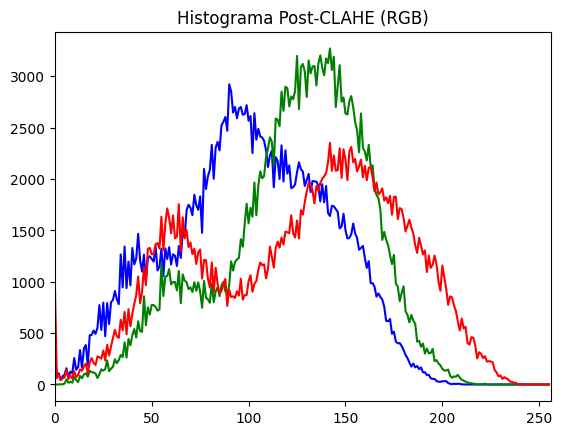

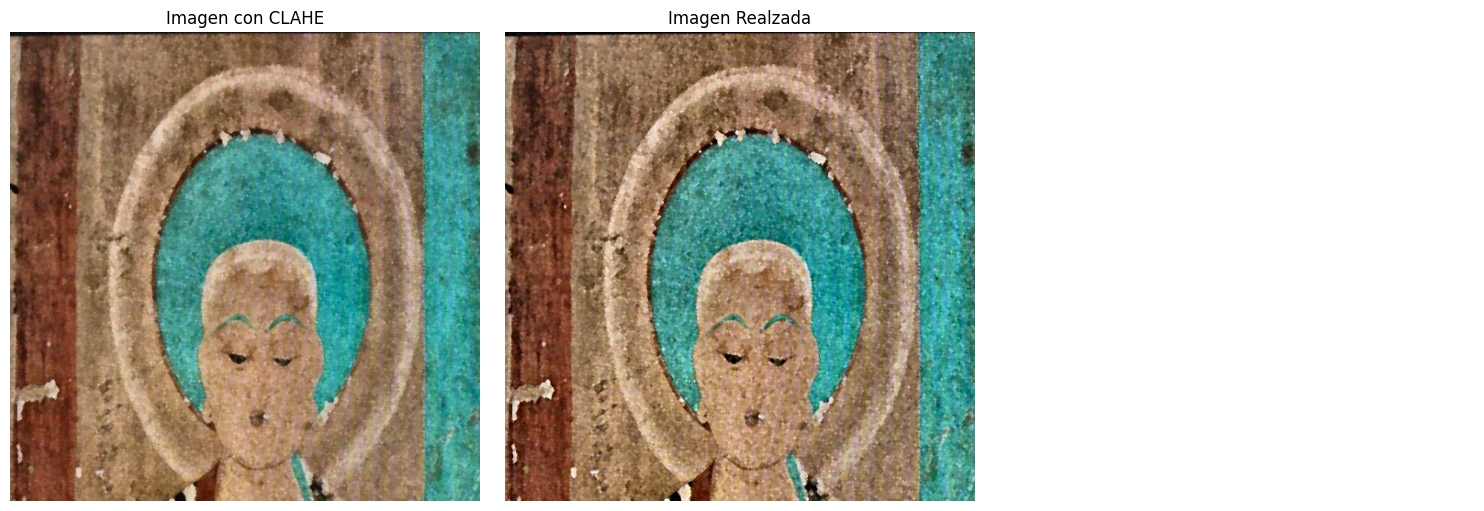

In [6]:
# --- Etapa 3: Realce y Recuperación de Detalles ---
print("\n--- Etapa 3: Realce y Recuperación de Detalles ---")

# 3.1 Ecualización de Histograma Adaptativa (CLAHE) para mejorar contraste local
# Convertir a L*a*b* para aplicar CLAHE solo al canal de luminancia (L)
img_lab = cv2.cvtColor(img_preprocesada, cv2.COLOR_BGR2LAB)
l_channel, a_channel, b_channel = cv2.split(img_lab)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
l_channel_clahe = clahe.apply(l_channel)

img_lab_clahe = cv2.merge((l_channel_clahe, a_channel, b_channel))
img_clahe = cv2.cvtColor(img_lab_clahe, cv2.COLOR_LAB2BGR)
mostrar_histograma(img_clahe, "Histograma Post-CLAHE")


# 3.2 Realce de Bordes (Máscara de Desenfoque - Unsharp Masking)
# Forma simple: original + (original - suavizado) = 2*original - suavizado
# O usando un kernel de realce
blurred_for_sharpen = cv2.GaussianBlur(img_clahe, (0,0), 3) # Kernel más pequeño para no perder el efecto CLAHE
img_realzada = cv2.addWeighted(img_clahe, 1.5, blurred_for_sharpen, -0.5, 0)
# kernel_sharpen = np.array([[-1, -1, -1],
#                            [-1,  9, -1],
#                            [-1, -1, -1]])
# img_realzada = cv2.filter2D(img_clahe, -1, kernel_sharpen)

show_images([img_clahe, img_realzada],
            titles=["Imagen con CLAHE", "Imagen Realzada"])

img_mejorada = img_realzada.copy()

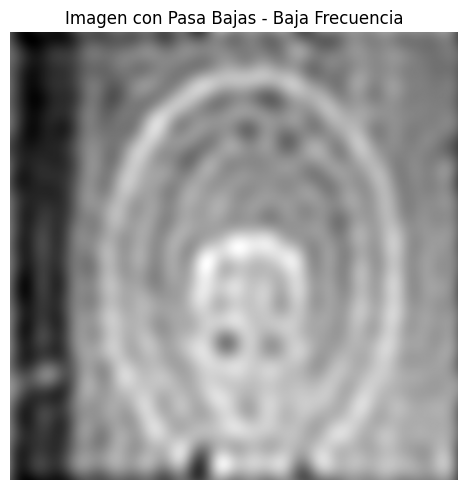

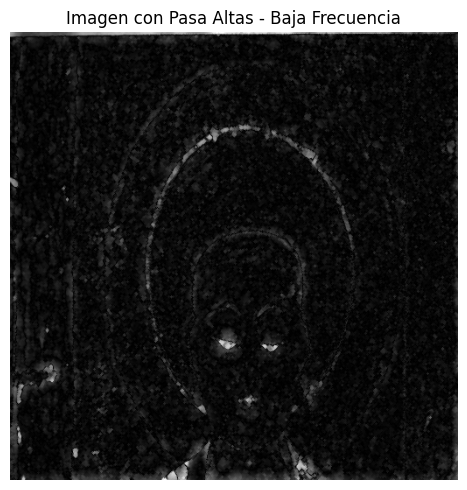

In [7]:
# --- Pruebas dominio frecuencial ---

# Convertir a escala de grises
img_gris = cv2.cvtColor(img_preprocesada, cv2.COLOR_BGR2GRAY)

# 2. Obtener el DFT centrado
dft_shift_bajas = calcular_dft_centrada(img_gris)

# 3. Crear máscaras para filtros
radio = 15 # Radio del filtro en píxeles
mascara_pasa_bajas_frecB = crear_mascara_frecuencia(img_gris.shape, radio, tipo='pasa_bajas')
mascara_pasa_altas_frecB = crear_mascara_frecuencia(img_gris.shape, radio, tipo='pasa_altas')


# 4. Aplicar filtros en frecuencia
dft_bajas_frecB = dft_shift_bajas * mascara_pasa_bajas_frecB
dft_altas_frecB = dft_shift_bajas * mascara_pasa_altas_frecB


# 5. Reconstrucción en el dominio espacial
img_bajas = reconstruir_imagen_idft(dft_bajas_frecB, mostrar=True, titulo='Imagen con Pasa Bajas - Baja Frecuencia')
img_altas = reconstruir_imagen_idft(dft_altas_frecB, mostrar=True, titulo='Imagen con Pasa Altas - Baja Frecuencia')


--- Etapa 3: Realce y Recuperación de Detalles ---


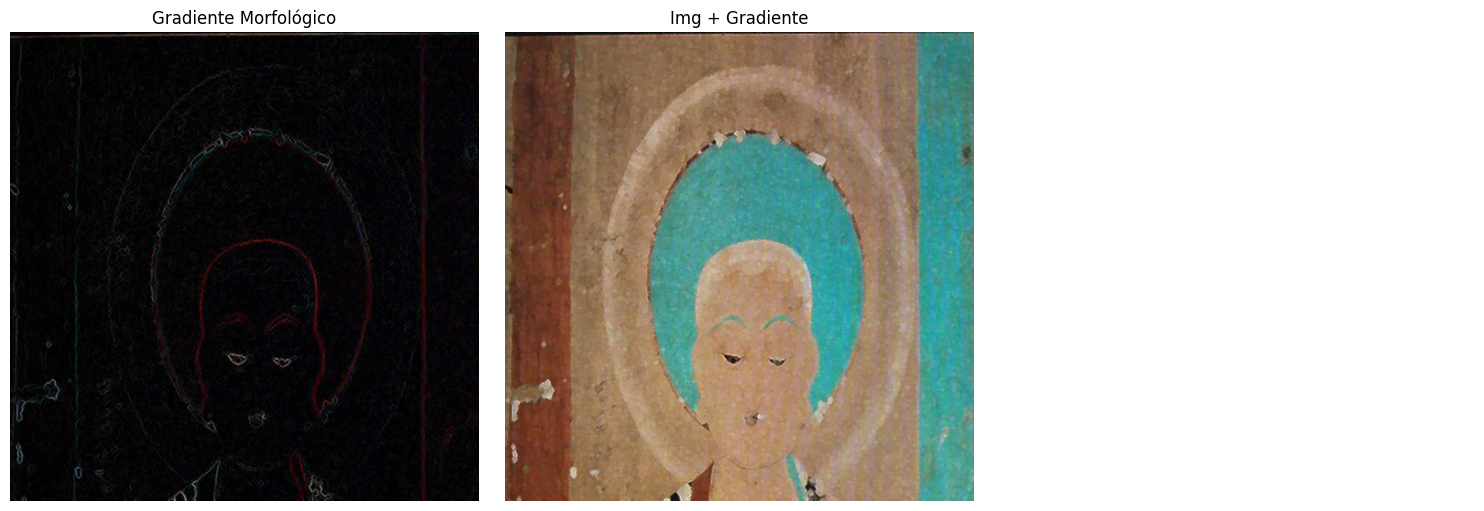

In [8]:
# --- Etapa 3: Realce y Recuperación de Detalles ---
print("\n--- Etapa 3: Realce y Recuperación de Detalles ---")

# Gradiente morfológico para detectar bordes
img_gradiente = cv2.morphologyEx(img_preprocesada, cv2.MORPH_GRADIENT, kernel)


# Marcar bordes en la imagen realzada
img_bordes = cv2.addWeighted(img_preprocesada, 1, img_gradiente, 0.7, 0)

show_images([img_gradiente, img_bordes],
            titles=["Gradiente Morfológico", "Img + Gradiente",])

In [9]:
def prewitt_filter(img):
    kernel_x = np.array([[-1, 0, 1],
                        [-1, 0, 1],
                        [-1, 0, 1]], dtype=np.float32)
    

    kernel_y = np.array([[ 1,  1,  1],
                        [ 0,  0,  0],
                        [-1, -1, -1]], dtype=np.float32)

    filtered_x = filtro_gris(img, kernel_x, uint8=False)
    filtered_y = filtro_gris(img, kernel_y, uint8=False)
    filtered = np.sqrt(filtered_x**2 + filtered_y**2)
    return np.clip(filtered, 0, 255).astype(np.uint8)


#laplaciano
def laplace_filter(img):
    mask = np.array([[0, 1, 0],[1, -4, 1],[0, 1, 0]], dtype=np.float32)
    return filtro_gris(img, mask)



def sobel_filter(img):
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    filtered_x = filtro_gris(img, sobel_x, uint8=False)
    filtered_y = filtro_gris(img, sobel_y, uint8=False)
    filtered = np.sqrt(filtered_x**2 + filtered_y**2)
    filtered = np.clip(filtered, 0, 255).astype(np.uint8)
    return filtered

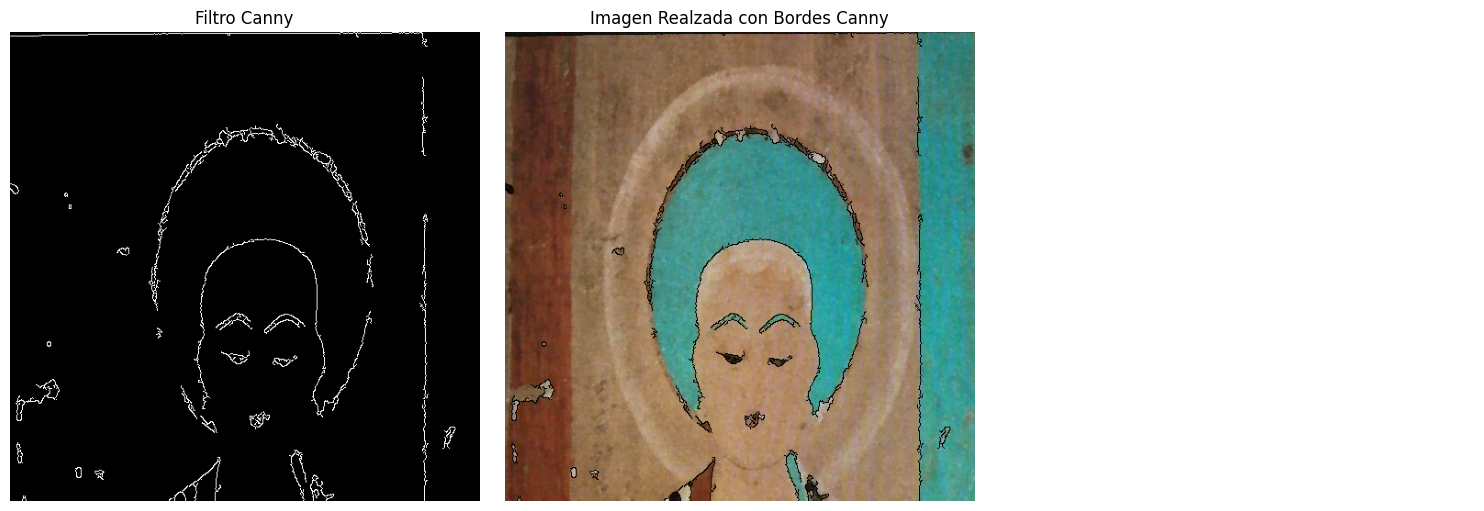

In [10]:
# --- Prueba filtros ----

# Filtro Canny
canny_img = cv2.Canny(img_preprocesada, 100, 300)

# Convertir Canny a 3 canales
canny_img_color = cv2.cvtColor(canny_img, cv2.COLOR_GRAY2BGR)

img_realzada_bordes = img_preprocesada.copy()

img_realzada_bordes[canny_img == 255] = [0, 0, 0] # BGR para negro

# Sumar bordes detectados a la imagen realzada
#img_realzada_bordes = cv2.addWeighted(img_preprocesada, 1, canny_img_color, 0.5, 0)

# Mostrar los resultados de los filtros
show_images([ canny_img, img_realzada_bordes],
            titles=["Filtro Canny", "Imagen Realzada con Bordes Canny"])

img_mejorada = img_realzada_bordes.copy()


--- Etapa 4: Segmentación de Áreas de Daño (Detectando Despintado/Ralladuras) ---


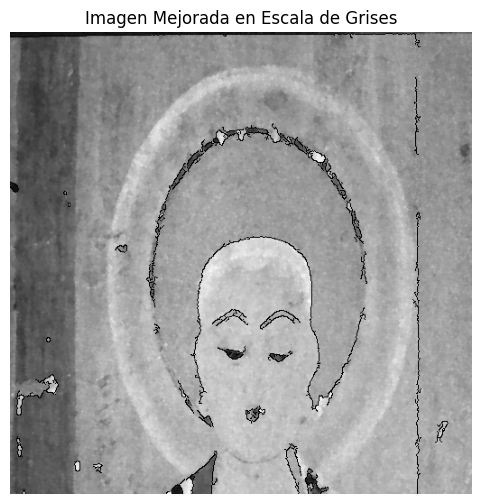

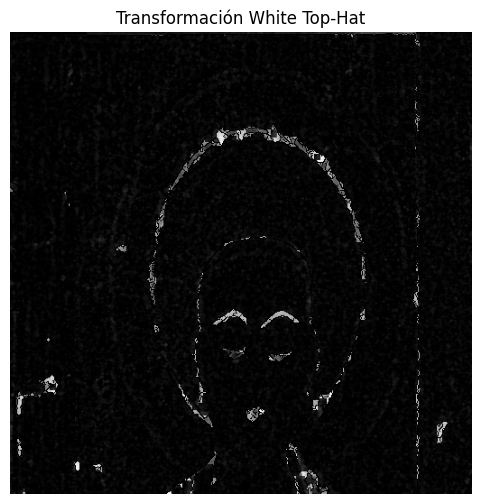

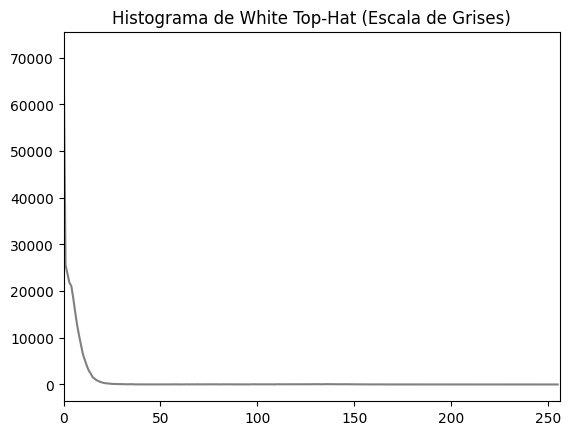

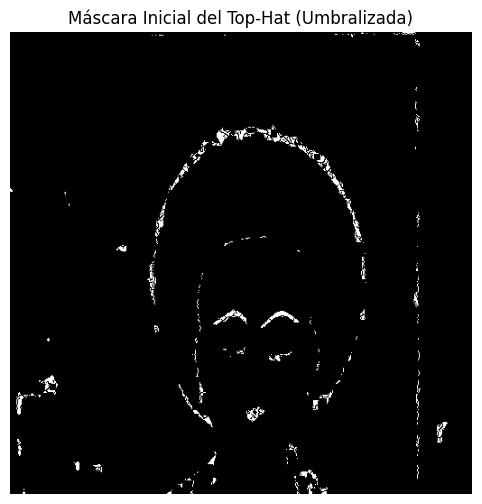

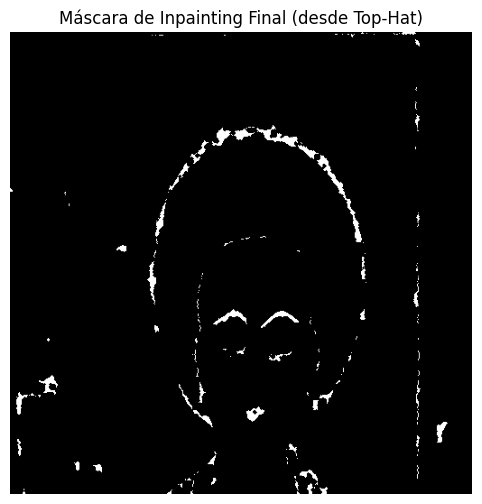

In [11]:
# --- Etapa 4: Segmentación y Aislamiento de Áreas de Daño (Detectando Despintado/Ralladuras) ---
print("\n--- Etapa 4: Segmentación de Áreas de Daño (Detectando Despintado/Ralladuras) ---")

# 4.1 Convertir a escala de grises para operaciones morfológicas
img_gris_para_mascara = cv2.cvtColor(img_mejorada, cv2.COLOR_BGR2GRAY)
mostrar_imagen("Imagen Mejorada en Escala de Grises", img_gris_para_mascara, cmap='gray')

# 4.2 Transformación Morfológica: White Top-Hat
# El White Top-Hat resalta los objetos pequeños y brillantes.
# Necesitamos un elemento estructurante (kernel). Su tamaño dependerá del tamaño
# de las ralladuras o puntos que quieras detectar.
# Un kernel rectangular puede ser bueno para ralladuras.
# Un kernel elíptico/circular para puntos. Probemos con uno rectangular pequeño.
# El tamaño debe ser MÁS GRANDE que las características que se quieren detectar.
# Si las ralladuras tienen 1-2 píxeles de ancho, un kernel de 5x5 o 7x7 podría funcionar.
# Si son más grandes, incrementa el tamaño.

# Kernel para detectar ralladuras delgadas y puntos (ajusta el tamaño según sea necesario)
# Para ralladuras más horizontales: kernel_tophat = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 3))
# Para ralladuras más verticales: kernel_tophat = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 15))
# Para puntos o ralladuras en cualquier dirección:
#kernel_tophat = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5)) # Para puntos y detalles finos
kernel_tophat = cv2.getStructuringElement(cv2.MORPH_RECT, (7,7)) # Alternativa

white_tophat = cv2.morphologyEx(img_gris_para_mascara, cv2.MORPH_TOPHAT, kernel_tophat)
mostrar_imagen("Transformación White Top-Hat", white_tophat, cmap='gray')
mostrar_histograma(white_tophat, "Histograma de White Top-Hat")

# 4.3 Umbralización del resultado del Top-Hat
# Las áreas resaltadas por el Top-Hat tendrán valores de píxel más altos.
# Necesitamos encontrar un umbral adecuado. Puedes probar con Otsu o un valor fijo.
# Un valor fijo puede ser más controlable si las características son consistentes.
# El histograma del Top-Hat puede ayudar a elegir este valor.
# Queremos que las ralladuras/puntos queden en blanco (255)
umbral_tophat_valor = 50 # Ajusta este valor. Si el histograma muestra un pico claro, usa Otsu.
#_, mascara_tophat_inicial = cv2.threshold(white_tophat, umbral_tophat_valor, 255, cv2.THRESH_BINARY)
_, mascara_tophat_inicial = cv2.threshold(white_tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) # Alternativa con Otsu
mostrar_imagen("Máscara Inicial del Top-Hat (Umbralizada)", mascara_tophat_inicial, cmap='gray')

# 4.4 Refinamiento de la Máscara (Opcional pero recomendado)
# Podemos usar operaciones morfológicas para limpiar la máscara:
# - Cierre: para rellenar pequeños huecos en las áreas detectadas (unir partes de una ralladura).
# - Apertura: para eliminar pequeños puntos de ruido si la umbralización fue muy sensible.

kernel_refinamiento = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))

# Aplicar Cierre para conectar componentes cercanos (ej. partes de una raya)
mascara_cerrada = cv2.morphologyEx(mascara_tophat_inicial, cv2.MORPH_CLOSE, kernel_refinamiento, iterations=1)
# mostrar_imagen("Máscara Después de Cierre", mascara_cerrada, cmap='gray')

# Aplicar Apertura para eliminar pequeños puntos de ruido (si es necesario)
#mascara_refinada = cv2.morphologyEx(mascara_cerrada, cv2.MORPH_OPEN, kernel_refinamiento, iterations=1)
#mostrar_imagen("Máscara Después de Apertura", mascara_refinada, cmap='gray')

mascara_inpaint = mascara_cerrada # Usamos la máscara después del cierre

mostrar_imagen("Máscara de Inpainting Final (desde Top-Hat)", mascara_inpaint, cmap='gray')

# (Si quieres combinar con Canny para bordes más definidos de áreas grandes)
# bordes_canny = cv2.Canny(img_gris_para_mascara, threshold1=50, threshold2=150)
# mascara_combinada = cv2.bitwise_or(mascara_inpaint, bordes_canny)
# mostrar_imagen("Máscara Combinada (TopHat + Canny)", mascara_combinada, cmap='gray')
# mascara_inpaint = mascara_combinada # Si decides usar la combinada


--- Etapa 5: Restauración (Inpainting) ---


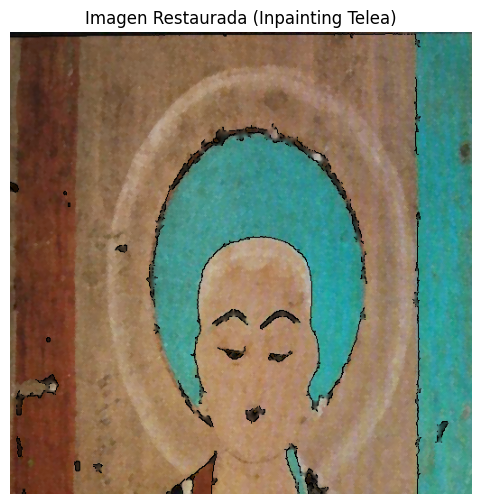

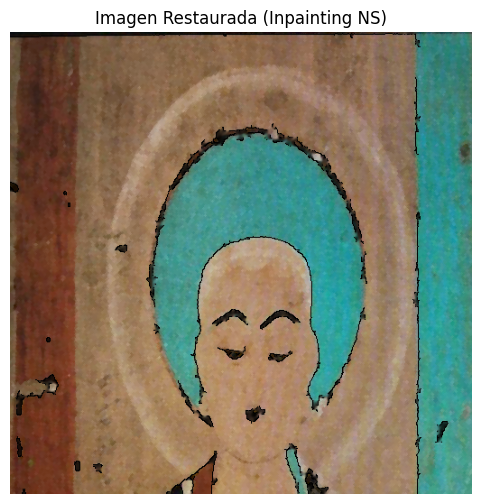

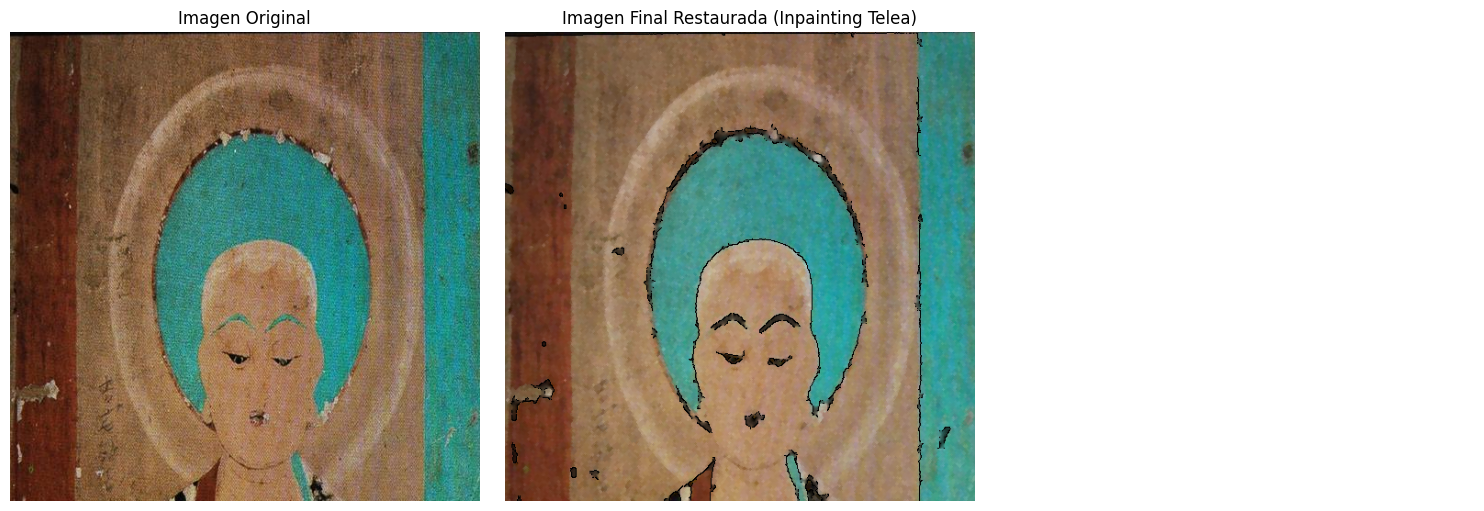

In [12]:
# --- Etapa 5: Técnicas de Restauración (Inpainting Básico) ---
# OpenCV ofrece dos algoritmos de inpainting.
# cv2.INPAINT_TELEA: Basado en el método de Telea "An Image Inpainting Technique Based on the Fast Marching Method".
# cv2.INPAINT_NS: Basado en el método de Navier-Stokes.
print("\n--- Etapa 5: Restauración (Inpainting) ---")

# Usamos la máscara manual 'mascara_inpaint' que creamos
# El tercer parámetro es el radio de la vecindad alrededor de un píxel que se usa para el inpainting.
img_restaurada_telea = cv2.inpaint(img_mejorada, mascara_inpaint, 5, cv2.INPAINT_TELEA)
mostrar_imagen("Imagen Restaurada (Inpainting Telea)", img_restaurada_telea)

img_restaurada_ns = cv2.inpaint(img_mejorada, mascara_inpaint, 5, cv2.INPAINT_NS)
mostrar_imagen("Imagen Restaurada (Inpainting NS)", img_restaurada_ns)

# Elegimos una para continuar (Telea suele ser más rápido, NS a veces mejor para texturas)
img_final_restaurada = img_restaurada_telea.copy()

# Motrar imágenes incluyebdo la original y la restaurada
show_images([img_original, img_final_restaurada],
            titles=["Imagen Original", "Imagen Final Restaurada (Inpainting Telea)"])

In [ ]:
# --- Etapa 6: Ajustes Finales y Guardado ---
print("\n--- Etapa 6: Ajustes Finales y Guardado ---")
# Aquí podrías aplicar ajustes finales de color, brillo, etc. de forma más sutil
# o realizar retoques manuales si esto fuera parte de un flujo interactivo.

# Ejemplo de un pequeño ajuste de brillo final si es necesario
# img_final_ajustada = cv2.convertScaleAbs(img_final_restaurada, alpha=1.0, beta=10) # alpha: contraste, beta: brillo
# mostrar_imagen("Imagen Final con Ajuste de Brillo", img_final_ajustada)
# img_para_guardar = img_final_ajustada

img_para_guardar = img_final_restaurada

# Guardar la imagen resultante
ruta_salida_tiff = 'mural_restaurado.tiff' # Formato sin pérdida
ruta_salida_jpeg = 'mural_restaurado.jpg'  # Formato con pérdida (alta calidad)

try:
    cv2.imwrite(ruta_salida_tiff, img_para_guardar)
    cv2.imwrite(ruta_salida_jpeg, img_para_guardar, [cv2.IMWRITE_JPEG_QUALITY, 95])
    print(f"Imagen restaurada guardada como '{ruta_salida_tiff}' y '{ruta_salida_jpeg}'")
except Exception as e:
    print(f"Error al guardar la imagen: {e}")

print("\n--- Proceso Completado ---")